In [1]:
import csv
import os
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import get_cmap
import numpy as np
import xarray as xr


# ── Column layout from the Nordicana D fixed-width spec ──────────────────────
#  01-05   data code
#  06-12   station code
#  13-21   latitude
#  22-30   longitude
#  31-34   year
#  35-36   month
#  37-38   day
#  39-58   substation code  (e.g. "                 T01")
#  59+     value

# Substation → depth label mapping (from the site metadata)
SUBSTATION_DEPTHS = {
    "T01": "25cm",
    "T02": "50cm",
    "T03": "75cm",
    "T04": "100cm",
    "T05": "150cm",
    "T06": "200cm",
    "T07": "300cm",
    "T08": "400cm",
    "T09": "500cm",
    "T10": "600cm",
    "T11": "700cm",
    "T12": "800cm",
    "T13": "900cm",
    "T14": "1000cm",
    "T15": "1200cm",
    "T16": "1500cm",
}

MISSING = -99999


def parse_line(line: str) -> dict | None:
    """Parse one fixed-width record. Returns None if line is too short or missing."""
    line = line.rstrip("\n")
    if len(line) < 59:
        return None

    data_code    = line[0:5].strip()
    station_code = line[5:12].strip()
    latitude     = line[12:21].strip()
    longitude    = line[21:30].strip()
    year         = int(line[30:34])
    month        = int(line[34:36])
    day          = int(line[36:38])
    substation   = line[38:58].strip()   # e.g. "T01", "T16"
    value_str    = line[58:].strip()

    try:
        value = float(value_str)
    except ValueError:
        return None

    if value == MISSING:
        value = None

    depth_label = SUBSTATION_DEPTHS.get(substation, substation)

    return {
        "date":         date(year, month, day).isoformat(),
        "station_code": station_code,
        "latitude":     latitude,
        "longitude":    longitude,
        "substation":   substation,
        "depth":        depth_label,
        "temperature_c": value,
        "data_code":    data_code,
    }


def parse_to_wide_csv(input_path: str, output_path: str) -> None:
    """
    Parse the fixed-width file and write a wide-format CSV where each column
    is a sensor depth, making it easy to plot all depths on one chart.

    Output columns:
        date, station_code, 25cm, 50cm, 75cm, ... 1500cm
    """
    # ── 1. Read all records ──────────────────────────────────────────────────
    records: dict[tuple, dict] = {}   # key = (date, station_code)

    #with open(input_path, "r", encoding="utf-16") as f:
    with open(input_path, "r", encoding="utf-16", errors="replace") as f:
        for raw in f:
            parsed = parse_line(raw)
            if parsed is None:
                continue
            key = (parsed["date"], parsed["station_code"])
            if key not in records:
                records[key] = {
                    "date":         parsed["date"],
                    "station_code": parsed["station_code"],
                    "latitude":     parsed["latitude"],
                    "longitude":    parsed["longitude"],
                }
            records[key][parsed["depth"]] = parsed["temperature_c"]

    # ── 2. Build ordered depth columns ──────────────────────────────────────
    depth_cols = list(SUBSTATION_DEPTHS.values())   # 25cm … 1500cm in order

    fieldnames = ["date", "station_code", "latitude", "longitude"] + depth_cols

    # ── 3. Write CSV (sorted by date) ────────────────────────────────────────
    rows = sorted(records.values(), key=lambda r: r["date"])

    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        for row in rows:
            # Fill missing depths with empty string
            for col in depth_cols:
                row.setdefault(col, "")
            writer.writerow(row)

    print(f"Wrote {len(rows)} rows → {output_path}")


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    INPUT_FILE  = "IQ_obs/soil_temp/ds_000633435_Jour_DLY.txt"   # ← change to your actual filename
    OUTPUT_FILE = "IQ_obs/soil_temp/borehole_temperatures.csv"

    if not os.path.exists(INPUT_FILE):
        print(f"File not found: {INPUT_FILE}")
    else:
        parse_to_wide_csv(INPUT_FILE, OUTPUT_FILE)

Wrote 1463 rows → IQ_obs/soil_temp/borehole_temperatures.csv


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("IQ_obs/soil_temp/borehole_temperatures.csv", parse_dates=["date"])

DEPTH_COLS = [
    "25cm", "50cm", "75cm", "100cm", "150cm", "200cm",
    "300cm", "400cm", "500cm", "600cm", "700cm", "800cm",
    "900cm", "1000cm", "1200cm", "1500cm",
]

depth_cols = [c for c in DEPTH_COLS if c in df.columns]

# ← add this block
depth_m = {
    "25cm": 0.25, "50cm": 0.50, "75cm": 0.75, "100cm": 1.0,
    "150cm": 1.5, "200cm": 2.0, "300cm": 3.0, "400cm": 4.0,
    "500cm": 5.0, "600cm": 6.0, "700cm": 7.0, "800cm": 8.0,
    "900cm": 9.0, "1000cm": 10.0, "1200cm": 12.0, "1500cm": 15.0,
}
# Keep only depth columns that actually exist in the file
depth_cols = [c for c in DEPTH_COLS if c in df.columns]

df = df.sort_values("date")

# ── Colour map: shallow = warm, deep = cool ──────────────────────────────────
cmap = get_cmap("viridis")
colors = [cmap(i / (len(depth_cols) - 1)) for i in range(len(depth_cols))]


C:\Users\madel\AppData\Local\Temp\ipykernel_37064\1915614937.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


Saved fig1_timeseries_all_depths.png


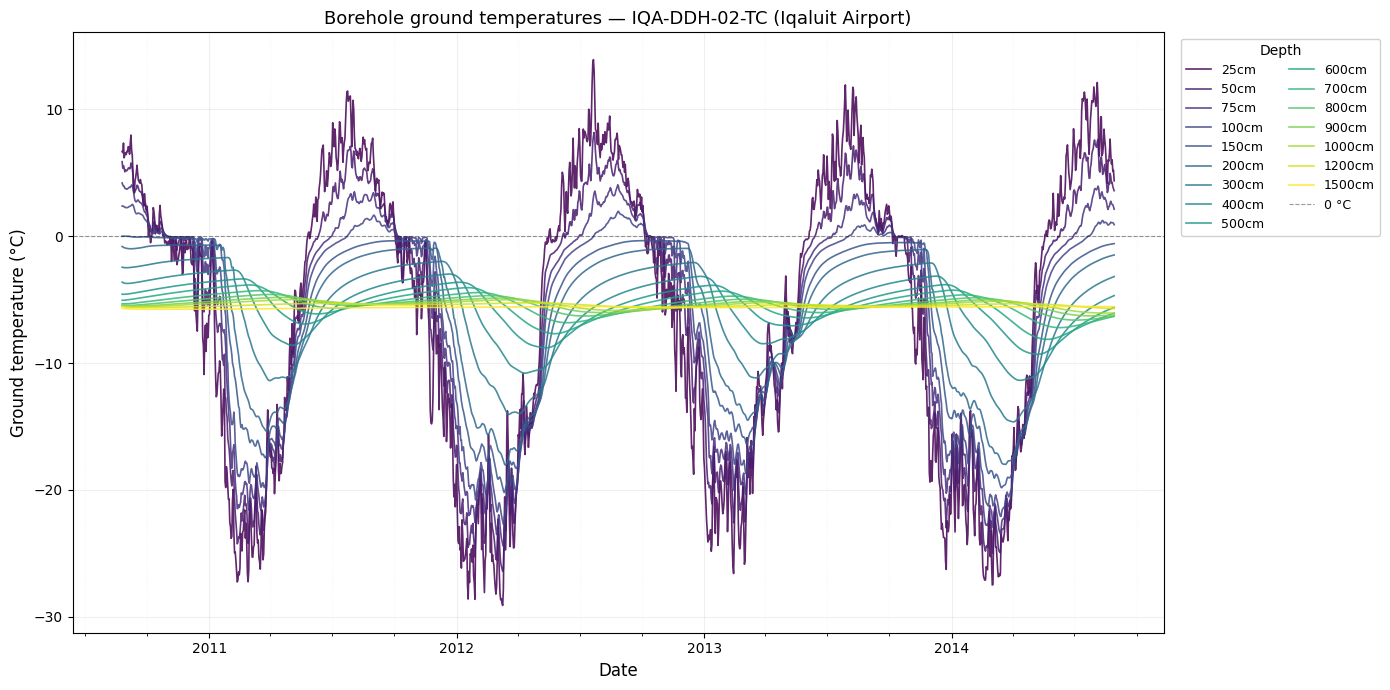

In [3]:

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — All depths on one chart (time series)
# ─────────────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 7))

for col, color in zip(depth_cols, colors):
    series = df[["date", col]].dropna()
    if series.empty:
        continue
    ax1.plot(
        series["date"], series[col],
        label=col, color=color, linewidth=1.2, alpha=0.85
    )

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4, label="0 °C")
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax1.grid(True, which="major", linestyle="-",  alpha=0.2)
ax1.grid(True, which="minor", linestyle=":",  alpha=0.12)
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Ground temperature (°C)", fontsize=12)
ax1.set_title("Borehole ground temperatures — IQA-DDH-02-TC (Iqaluit Airport)", fontsize=13)

# Legend outside plot, two columns
ax1.legend(
    title="Depth", title_fontsize=10,
    loc="upper left", bbox_to_anchor=(1.01, 1),
    fontsize=9, ncol=2, framealpha=0.9
)
fig1.tight_layout()
fig1.savefig("fig1_timeseries_all_depths.png", dpi=150, bbox_inches="tight")
print("Saved fig1_timeseries_all_depths.png")



August averages available for years: [2010, 2011, 2012, 2013, 2014]
Saved fig_august_depth_profiles.png


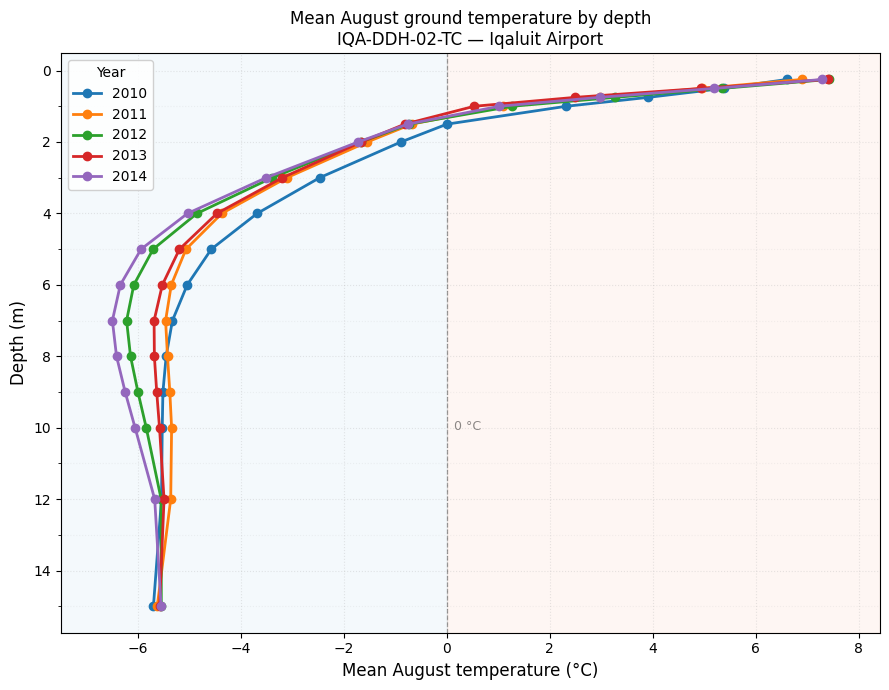

In [4]:
# ── Filter to August only, then average by year ───────────────────────────────
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

august = df[df["month"] == 8].copy()
august_avg = august.groupby("year")[depth_cols].mean()

years = august_avg.index.tolist()
print(f"August averages available for years: {years}")

# ── Colour palette — one colour per year ─────────────────────────────────────
colors = ["#E24B4A", "#EF9F27", "#1D9E75", "#378ADD"]  # red, amber, teal, blue
# Extend automatically if there are more than 4 years
if len(years) > len(colors):
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(years))]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for year, color in zip(years, colors):
    row = august_avg.loc[year]
    temps  = [row[c] for c in depth_cols if pd.notna(row[c])]
    depths = [depth_m[c] for c in depth_cols if pd.notna(row[c])]

    ax.plot(temps, depths, "o-", color=color, linewidth=2,
            markersize=6, label=str(year), zorder=3)

# 0 °C reference line
ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
ax.text(0.15, 0.35, "0 °C", fontsize=9, color="black", alpha=0.45,
        transform=ax.get_xaxis_transform())

# Shade freezing zone
xlim_pad = 1
all_temps = august_avg[depth_cols].values.flatten()
xmin = np.nanmin(all_temps) - xlim_pad
xmax = np.nanmax(all_temps) + xlim_pad
ax.axvspan(xmin, 0, color="#6baed6", alpha=0.07, zorder=1)
ax.axvspan(0, xmax, color="#fc8d59", alpha=0.07, zorder=1)

ax.invert_yaxis()
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Mean August temperature (°C)", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
ax.set_title(
    "Mean August ground temperature by depth\nIQA-DDH-02-TC — Iqaluit Airport",
    fontsize=12
)
ax.legend(title="Year", fontsize=10, title_fontsize=10, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.3)
ax.yaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

fig.tight_layout()
fig.savefig("fig_august_depth_profiles.png", dpi=150, bbox_inches="tight")
print("Saved fig_august_depth_profiles.png")
plt.show()

Saved fig3_heatmap.png


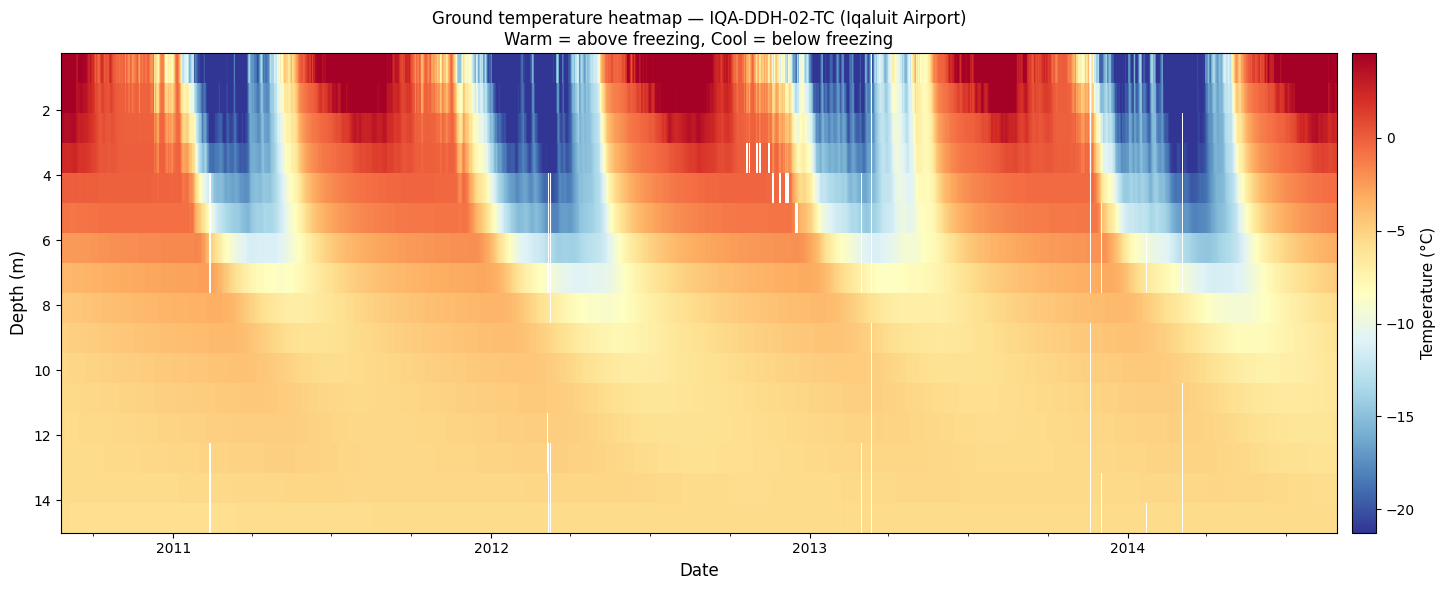

In [5]:


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Heatmap: date (x) vs depth (y), colour = temperature
#             Great for spotting seasonal cycles and long-term trends.
# ─────────────────────────────────────────────────────────────────────────────
# Build a matrix: rows = depths, columns = dates
matrix = df.set_index("date")[depth_cols].T   # shape: (n_depths, n_dates)

fig3, ax3 = plt.subplots(figsize=(16, 6))

# Convert dates to numeric for imshow x-axis
date_nums = mdates.date2num(df["date"].values)
depth_labels = [depth_m[c] for c in depth_cols]

im = ax3.imshow(
    matrix.values,
    aspect="auto",
    origin="upper",
    extent=[date_nums[0], date_nums[-1], depth_labels[-1], depth_labels[0]],
    cmap="RdYlBu_r",
    vmin=np.nanpercentile(matrix.values, 2),
    vmax=np.nanpercentile(matrix.values, 98),
    interpolation="nearest",
)

ax3.xaxis_date()
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

cbar = fig3.colorbar(im, ax=ax3, pad=0.01)
cbar.set_label("Temperature (°C)", fontsize=11)

ax3.set_xlabel("Date", fontsize=12)
ax3.set_ylabel("Depth (m)", fontsize=12)
ax3.set_title(
    "Ground temperature heatmap — IQA-DDH-02-TC (Iqaluit Airport)\n"
    "Warm = above freezing, Cool = below freezing",
    fontsize=12
)
fig3.tight_layout()
fig3.savefig("fig3_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved fig3_heatmap.png")

plt.show()

Averaged over 129+ August days across years: [np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014)]
Saved fig_august_mean_profile.png


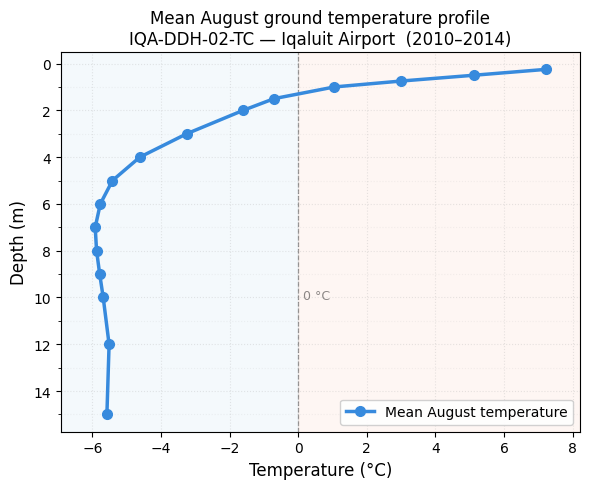

In [6]:
# ── Load data ────────────────────────────────────────────────────────────────
#df = pd.read_csv("borehole_temperatures.csv", parse_dates=["date"])

DEPTH_COLS = [
    "25cm", "50cm", "75cm", "100cm", "150cm", "200cm",
    "300cm", "400cm", "500cm", "600cm", "700cm", "800cm",
    "900cm", "1000cm", "1200cm", "1500cm",
]
depth_cols = [c for c in DEPTH_COLS if c in df.columns]

depth_m = {
    "25cm": 0.25, "50cm": 0.50, "75cm": 0.75, "100cm": 1.0,
    "150cm": 1.5, "200cm": 2.0, "300cm": 3.0, "400cm": 4.0,
    "500cm": 5.0, "600cm": 6.0, "700cm": 7.0, "800cm": 8.0,
    "900cm": 9.0, "1000cm": 10.0, "1200cm": 12.0, "1500cm": 15.0,
}

# ── Average all August days across all years into one profile ─────────────────
august = df[df["date"].dt.month == 8].copy()
avg    = august[depth_cols].mean()
std    = august[depth_cols].std()

temps  = [avg[c]           for c in depth_cols if pd.notna(avg[c])]
stds   = [std[c]           for c in depth_cols if pd.notna(avg[c])]
depths = [depth_m[c]       for c in depth_cols if pd.notna(avg[c])]
n_days = august[depth_cols].count().min()

print(f"Averaged over {n_days}+ August days across years: {sorted(august['date'].dt.year.unique())}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

# Shaded ±1 std deviation band
# ax.fill_betweenx(
#     depths,
#     [t - s for t, s in zip(temps, stds)],
#     [t + s for t, s in zip(temps, stds)],
#     color="#378ADD", alpha=0.15, label="±1 std dev"
# )

# Mean profile line
ax.plot(temps, depths, "o-", color="#378ADD", linewidth=2.5,
        markersize=7, zorder=3, label="Mean August temperature")

# 0 °C reference
ax.axvline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.35, zorder=2)
ax.text(0.15, 0.35, "0 °C", fontsize=9, color="black", alpha=0.45,
        transform=ax.get_xaxis_transform())

# Freeze/thaw shading
all_vals = np.array(temps)
xmin = np.nanmin(all_vals) - 1
xmax = np.nanmax(all_vals) + 1
ax.axvspan(xmin, 0,    color="#6baed6", alpha=0.07, zorder=1)
ax.axvspan(0,    xmax, color="#fc8d59", alpha=0.07, zorder=1)

ax.invert_yaxis()
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
ax.set_title(
    f"Mean August ground temperature profile\n"
    f"IQA-DDH-02-TC — Iqaluit Airport  "
    f"({august['date'].dt.year.min()}–{august['date'].dt.year.max()})",
    fontsize=12
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.3)
ax.yaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

fig.tight_layout()
fig.savefig("fig_august_mean_profile.png", dpi=150, bbox_inches="tight")
print("Saved fig_august_mean_profile.png")
plt.show()

In [7]:
site = "IQ"
ctsm_file = "IQ_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")
var_soilt = df["TSOI"]
var_soilt

C:\Users\madel\AppData\Local\Temp\ipykernel_37064\2453725558.py:3: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


<xarray.DataArray 'TSOI' (time: 7300, levgrnd: 25, lndgrid: 1)> Size: 730kB
[182500 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg